# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Kevin Arancibia Calderón
*   Alumno 2: Cristina López Blanco
*   Alumno 3: Marian Milad Fernández
*   Alumno 4: Eric Serret Llopis

**Objetivo:** Superar el primer día de carrera durante 100 episodios consecutivos

https://ale.farama.org/environments/enduro/

---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [ ]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/08 MIAR - Aprendizaje por refuerzo/Proyecto"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [3]:
# Switch to the directory on the Google Drive that you want to use
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    # Mount the Google Drive at mount
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Create drive_root if it doesn't exist
    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    # Change to the directory
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
# Verify we're in the correct working directory
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

---
### 1.4. Instalar librerías necesarias

In [3]:
if IN_COLAB:
  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [2]:
#Comprobamos que se carga la versión esperada de TF y detecta la GPU
import os
import tensorflow.keras as tf
import tensorflow as tf1

os.environ['TF_USE_LEGACY_KERAS']="1"

gpus = tf1.config.list_physical_devices('GPU')
for gpu in gpus:
    tf1.config.experimental.set_memory_growth(gpu, True)

from keras import __version__
tf.__version__ = __version__

print(tf1.__version__)
print(tf1.config.list_physical_devices('GPU'))
print(tf1.config.list_logical_devices('GPU'))

Using TensorFlow backend.


2.5.3
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [3]:
from __future__ import division

from PIL import Image
import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Convolution2D, Permute, Dropout

if IN_COLAB:
  from tensorflow.keras.optimizers.legacy import Adam
else:
  from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

#### Configuración base

Antes de comenzar a afrontar el problema es necesario entender el entorno en el que se está trabajando, ya que el conocimiento del problema a afrontar permitirá adaptar mejor los parámetros a seleccionar. El entorno asignado al grupo es “Enduro”, un videojuego de Atari que salió a la venta en 1983. Básicamente este videojuego consiste en una carrera de coches en la cual cada capítulo del videojuego corresponde a un día distinto. Para seguir en carrera al final de cada capítulo se exige que nuestro coche adelante una cierta cantidad de coches que incrementa en cada capítulo: En el caso que nos ocupa, que es pasar a la siguiente pantalla, este número de adelantamientos es 200 para el primer día. 

Por propósitos de investigación, se jugó a un par de partidas a este juego y se descubrió que las recompensas, es decir, los coches a adelantar, están distribuidas de una manera bastante uniforme a lo largo de todo el videojuego. Por ello se hace necesario utilizar un factor gamma elevado, con el objetivo de que el modelo no se conforme con adelantar a un par de coches y luego se “relaje”, pues debe tener un rendimiento constantemente elevado a lo largo de toda la partida. 

Por otra parte, será necesario entrenar el modelo también con un gran número de pasos: Es un juego relativamente complejo en comparación con otros de atari, pues el agente puede ejecutar 9 acciones distintas en cada momento. Será importante también por este motivo comenzar con un factor epsilon elevado que lo haga bueno explorando el entorno. Una vez hechas las suposiciones iniciales, es momento de  pasar a entrenar los modelos bajo estas directrices. 

In [4]:
def get_paths(env_name, variant):
    variant_dir = os.path.join(variant)
    os.makedirs(variant_dir, exist_ok=True)


    prefix = f"dqn_{env_name}_{variant}"

    return {
        "weights": os.path.join(variant_dir, f"{prefix}_weights.h5f"),
        "checkpoint": os.path.join(variant_dir, f"{prefix}_weights_" + "{step}.h5f"),
        "log": os.path.join(variant_dir, f"{prefix}_log.json"),
    }

In [5]:
# Descomentar y adaptar a cada entorno según corresponda
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

env_name = 'Enduro-v0'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)
nb_actions = env.action_space.n

In [6]:
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)

In [7]:
print("Número de acciones disponibles: " + str(nb_actions))

Número de acciones disponibles: 9


In [8]:
print("Formato de las observaciones:")
env.observation_space

Formato de las observaciones:


Box(0, 255, (210, 160, 3), uint8)

## 1. Implementación de la red neuronal

In [10]:
def build_model(window_length, input_shape, nb_actions, show_summary=True):
    full_input_shape = (window_length,) + input_shape
    model = Sequential()
    if K.image_data_format() == 'channels_last':
        model.add(Permute((2, 3, 1), input_shape=full_input_shape))
    elif K.image_data_format() == 'channels_first':
        model.add(Permute((1, 2, 3), input_shape=full_input_shape))
    else:
        raise RuntimeError('Unknown image_dim_ordering.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions))
    model.add(Activation('linear'))
    if show_summary==True:
        model.summary()
    return model

## 2. Implementación de las soluciones DQN

In [9]:
NB_STEPS_TOTAL     = 1_700_000   
MEMORY_LIMIT       = 1_000_000
NB_STEPS_WARMUP    = 50_000     
TARGET_MODEL_UPDATE = 10_000
TRAIN_INTERVAL     = 4
POLICY_NB_STEPS    = 1_000_000  

### Primer modelo (baseline)

La arquitectura empleada como baseline está formada por tres capas convolucionales seguidas de una capa completamente conectada de 512 neuronas. Se trata de una arquitectura ampliamente utilizada y capaz de extraer las características visuales del entorno sin incrementar innecesariamente la complejidad del modelo.

Los parámetros han ido variando a medida que se ha ido iterando en el proyecto: En un principio se comenzó en el primer modelo con tan solo 500000 pasos. Sin embargo, esto pronto se reveló insuficiente pues el modelo no era capaz de adelantar ni siquiera un coche con esa cantidad. Es por este motivo que se decidió aumentar por mucho los pasos, hasta llegar a una línea base de 1,5 millones de pasos. En este punto, el coche ya fue capaz de adelantar a algunos coches y llegar a pasar en test al día 2, pero para mejorar estas cantidades iniciales se decidió entrenar la red principal unos 200000 pasos más para mejorar el resultado, lo cual logró que ahora el agente superase con creces el día 1 en casi todas las ocasiones para la DQN tradicional. 

Se utilizó un learning rate de 0.00025, lo suficientemente pequeño para favorecer un aprendizaje estable sin producir cambios bruscos en los pesos de la red y la memoria de repetición se fijó en 1.000.000 de transiciones para disponer de una gran variedad de experiencias. Además, se empleó un periodo de 50.000 pasos de warm-up, permitiendo llenar  la memoria antes de comenzar a actualizar la red. La red objetivo se actualizó cada 10.000 pasos, evitando que los valores objetivo cambiasen continuamente y consiguiendo un entrenamiento más estable. Finalmente, la exploración se redujo de forma lineal durante el primer millón de pasos para favorecer que el agente explorase ampliamente el entorno al principio y fuese explotando progresivamente la política aprendida.

In [11]:
variant_name = "model1"

paths = get_paths(env_name, variant_name)

weights_filename = paths["weights"]
checkpoint_weights_filename = paths["checkpoint"]
log_filename = paths["log"]

In [14]:
model = build_model(WINDOW_LENGTH, INPUT_SHAPE, nb_actions)
memory = SequentialMemory(limit=MEMORY_LIMIT, window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=POLICY_NB_STEPS
)

dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    policy=policy,
    memory=memory,
    processor=processor,
    nb_steps_warmup=NB_STEPS_WARMUP,
    gamma=.99,
    target_model_update=TARGET_MODEL_UPDATE,
    train_interval=TRAIN_INTERVAL
)

dqn.compile(Adam(learning_rate=.00025), metrics=['mae'])

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
permute_1 (Permute)          (None, 84, 84, 4)         0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 20, 20, 32)        8224      
_________________________________________________________________
activation_5 (Activation)    (None, 20, 20, 32)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 9, 9, 64)          32832     
_________________________________________________________________
activation_6 (Activation)    (None, 9, 9, 64)          0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 7, 7, 64)          36928     
_________________________________________________________________
activation_7 (Activation)    (None, 7, 7, 64)         

In [16]:
callbacks = [ModelIntervalCheckpoint(checkpoint_weights_filename, interval=25000)]
callbacks += [FileLogger(log_filename, interval=500)]

history = dqn.fit(
    env, callbacks=callbacks,
    nb_steps=NB_STEPS_TOTAL,
    log_interval=10000,
    visualize=False
)

dqn.save_weights(weights_filename, overwrite=True)

Training for 1500000 steps ...
Interval 1 (0 steps performed)


C:\Users\116cl\anaconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


10000/10000 [==============================] - 53s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 58s 6ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 58s 6ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 53s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 55s 6ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/10000 [==============================] - 307s 31ms/step - reward

In [25]:
dqn.load_weights(weights_filename)
historial_test1 = dqn.test(env, nb_episodes=100, visualize=False)
recompensas_model1 = historial_test1.history['episode_reward']
media_test = np.mean(recompensas_model1)
print(f"Media de recompensa en test: {media_test}")

Testing for 100 episodes ...
Episode 1: reward: 367.000, steps: 8852
Episode 2: reward: 471.000, steps: 8851
Episode 3: reward: 172.000, steps: 4429
Episode 4: reward: 399.000, steps: 8855
Episode 5: reward: 415.000, steps: 8888
Episode 6: reward: 439.000, steps: 8884
Episode 7: reward: 380.000, steps: 8867
Episode 8: reward: 199.000, steps: 4433
Episode 9: reward: 456.000, steps: 8854
Episode 10: reward: 464.000, steps: 8894
Episode 11: reward: 427.000, steps: 8910
Episode 12: reward: 410.000, steps: 8889
Episode 13: reward: 193.000, steps: 4409
Episode 14: reward: 468.000, steps: 8827
Episode 15: reward: 379.000, steps: 8902
Episode 16: reward: 413.000, steps: 8893
Episode 17: reward: 367.000, steps: 8893
Episode 18: reward: 477.000, steps: 8876
Episode 19: reward: 443.000, steps: 8892
Episode 20: reward: 375.000, steps: 8853
Episode 21: reward: 403.000, steps: 8860
Episode 22: reward: 412.000, steps: 8828
Episode 23: reward: 432.000, steps: 8887
Episode 24: reward: 414.000, steps: 8

Con esta configuración, el modelo obtuvo una recompensa media de 382.49 puntos en los 100 episodios de test. La mayoría de las partidas alcanzaron alrededor de 8.900 pasos, lo que indica que el agente conseguía mantenerse en carrera de forma consistente y superar el primer día con frecuencia. Sin embargo, todavía aparecieron algunos episodios que finalizaban aproximadamente a los 4.400 pasos, lo que refleja que la DQN base aún presenta cierta variabilidad y margen de mejora. Estos resultados constituyen una referencia adecuada sobre la que evaluar las modificaciones introducidas en los siguientes modelos.

In [26]:
import json

os.makedirs('test', exist_ok=True)

test_model1 = {
    "nombre": "Modelo 1: Red Base",
    "recompensas": [float(r) for r in recompensas_model1], 
    "media": float(np.mean(recompensas_model1))
}

# Guardamos en un archivo JSON
with open('test/model1.json', 'w') as f:
    json.dump(test_model1, f, indent=4)

### Segundo modelo - Double DQN

Este modelo emplea Double DQN; una variante que modifica el cálculo del valor objetivo utilizado durante el entrenamiento. Mientras que la DQN tradicional emplea la misma red para seleccionar y evaluar la acción con mayor valor Q, Double DQN utiliza la red principal para seleccionar la acción y la red objetivo para estimar su valor. Esta separación reduce el sesgo de sobreestimación de los valores Q, uno de los principales problemas de la DQN original, y suele traducirse en políticas más estables y robustas.

Para ahorrar tiempo y tiempo de cómputo, pues entrenar los 1,5 millones de pasos llevó varias horas en la DQN tradicional, se decidió reutilizar este conjunto de 1,5 millones de datos inicial y, como en el caso de la DQN tradicional, se le añadieron 200000 pasos extra de entrenamiento con la Double DQN, manteniendo exactamente los mismos parámetros que con la DQN tradicional para hacerla más comparable. Sin embargo, los resultados obtenidos fueron inferiores a los esperados, ya que el rendimiento apenas mejoraba respecto a la línea base e incluso empeoraba en algunos experimentos. Una posible explicación es que el cambio al algoritmo Double DQN requiriese un periodo de adaptación mayor para reajustar las estimaciones de los valores Q sin modificar en exceso la política ya aprendida.

Por este motivo se introdujeron dos cambios. En primer lugar, se aumentó el entrenamiento adicional hasta 300.000 pasos, permitiendo al modelo disponer de más tiempo para adaptarse al nuevo método de actualización. En segundo lugar, se redujo el learning rate desde 0.00025 hasta 0.00005, buscando que las actualizaciones de los pesos fueran más pequeñas y conservadoras, minimizando cambios bruscos sobre una política que ya ofrecía un buen rendimiento. El resto de hiperparámetros se mantuvieron idénticos a los del baseline para que la comparación dependiera únicamente de la incorporación de Double DQN.


In [38]:
variant_name = "model2"

paths = get_paths(env_name, variant_name)

weights_filename = paths["weights"]
checkpoint_weights_filename = paths["checkpoint"]
log_filename = paths["log"]

In [39]:
model = build_model(WINDOW_LENGTH, INPUT_SHAPE, nb_actions)
memory = SequentialMemory(limit=MEMORY_LIMIT, window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=POLICY_NB_STEPS
)

dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    policy=policy,
    memory=memory,
    processor=processor,
    nb_steps_warmup=NB_STEPS_WARMUP,
    gamma=.99,
    target_model_update=TARGET_MODEL_UPDATE,
    train_interval=TRAIN_INTERVAL, 
    enable_double_dqn=True
)

dqn.compile(Adam(learning_rate=.00005), metrics=['mae'])

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
permute_4 (Permute)          (None, 84, 84, 4)         0         
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 20, 20, 32)        8224      
_________________________________________________________________
activation_20 (Activation)   (None, 20, 20, 32)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 9, 9, 64)          32832     
_________________________________________________________________
activation_21 (Activation)   (None, 9, 9, 64)          0         
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 7, 7, 64)          36928     
_________________________________________________________________
activation_22 (Activation)   (None, 7, 7, 64)         

In [ ]:
BASE_VARIANT = "model1"
base_weights_path = get_paths(env_name, BASE_VARIANT)["weights"]
dqn.load_weights(base_weights_path)

callbacks = [ModelIntervalCheckpoint(checkpoint_weights_filename, interval=25000)]
callbacks += [FileLogger(log_filename, interval=500)]

EXTRA_STEPS = 300_000
history = dqn.fit(
    env,
    callbacks=callbacks,
    nb_steps=EXTRA_STEPS,
    log_interval=10000,
    visualize=False
)

dqn.save_weights(weights_filename, overwrite=True)

In [40]:
dqn.load_weights(weights_filename)
historial_test2 = dqn.test(env, nb_episodes=100, visualize=False)
recompensas_model2 = historial_test2.history['episode_reward']
media_test = np.mean(recompensas_model2)
print(f"Media de recompensa en test: {media_test}")

Testing for 100 episodes ...
Episode 1: reward: 394.000, steps: 8859
Episode 2: reward: 384.000, steps: 8876
Episode 3: reward: 378.000, steps: 8854
Episode 4: reward: 408.000, steps: 8835
Episode 5: reward: 394.000, steps: 8892
Episode 6: reward: 356.000, steps: 8877
Episode 7: reward: 393.000, steps: 8913
Episode 8: reward: 388.000, steps: 8823
Episode 9: reward: 403.000, steps: 8878
Episode 10: reward: 365.000, steps: 8878
Episode 11: reward: 342.000, steps: 8882
Episode 12: reward: 416.000, steps: 8920
Episode 13: reward: 423.000, steps: 8885
Episode 14: reward: 425.000, steps: 8841
Episode 15: reward: 454.000, steps: 8904
Episode 16: reward: 445.000, steps: 8852
Episode 17: reward: 411.000, steps: 8813
Episode 18: reward: 404.000, steps: 8861
Episode 19: reward: 426.000, steps: 8838
Episode 20: reward: 370.000, steps: 8892
Episode 21: reward: 400.000, steps: 8875
Episode 22: reward: 185.000, steps: 4442
Episode 23: reward: 467.000, steps: 8887
Episode 24: reward: 366.000, steps: 8

Con esta configuración, el modelo obtuvo una recompensa media de 366.53 puntos, ligeramente inferior a la alcanzada por la DQN tradicional (382.49 puntos). Aunque la mayoría de los episodios volvieron a situarse alrededor de 8.900 pasos, siguieron apareciendo algunas partidas que finalizaban en torno a los 4.400 pasos, reduciendo la media final. En consecuencia, para este problema concreto la incorporación de Double DQN no consiguió mejorar el rendimiento de la línea base, lo que sugiere que la DQN convencional ya proporcionaba una política suficientemente estable para este entorno o que serían necesarios más pasos de entrenamiento para aprovechar las ventajas de este algoritmo. 

In [41]:
import json

os.makedirs('test', exist_ok=True)

test_model2 = {
    "nombre": "Modelo 2: Double DQN",
    "recompensas": [float(r) for r in recompensas_model2], 
    "media": float(np.mean(recompensas_model2))
}

# Guardamos en un archivo JSON
with open('test/model2.json', 'w') as f:
    json.dump(test_model2, f, indent=4)

### Modelo 3 - Double DQN + Dueling 

En este tercer modelo se incorporaron dos mejoras sobre la DQN tradicional: Double DQN y Dueling DQN. A diferencia del experimento anterior, este modelo se entrenó desde cero, manteniendo los mismos hiperparámetros utilizados en el baseline. De esta forma, el único cambio respecto al modelo original fue la incorporación de ambas mejoras, permitiendo evaluar su impacto sin que los resultados estuvieran condicionados por un entrenamiento previo. En este caso se mantuvieron los mismos hiperparámetros que en la DQN tradicional, incluido el learning rate de 0.00025, con el objetivo de evaluar el efecto de estas dos mejoras sin introducir cambios adicionales.

Dueling DQN se trata de una una variante que modifica la arquitectura de la red neuronal. En lugar de estimar directamente el valor Q de cada acción, la red se divide en dos ramas: una estima el valor del estado (State Value), es decir, lo favorable que es la situación actual independientemente de la acción elegida, y la otra estima la ventaja (Advantage) de realizar cada acción en ese estado. Ambas estimaciones se combinan posteriormente para obtener los valores Q finales. En este experimento se empleó la variante dueling_type='avg', que combina ambas estimaciones mediante la resta de la ventaja media, siendo una de las configuraciones más habituales por su estabilidad durante el entrenamiento.

In [ ]:
variant_name = "model3"

paths = get_paths(env_name, variant_name)

weights_filename = paths["weights"]
checkpoint_weights_filename = paths["checkpoint"]
log_filename = paths["log"]

In [ ]:
model = build_model(WINDOW_LENGTH, INPUT_SHAPE, nb_actions)

memory = SequentialMemory(limit=MEMORY_LIMIT, window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=POLICY_NB_STEPS
)

dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    policy=policy,
    memory=memory,
    processor=processor,
    nb_steps_warmup=NB_STEPS_WARMUP,
    gamma=.99,
    target_model_update=TARGET_MODEL_UPDATE,
    train_interval=TRAIN_INTERVAL,
    enable_double_dqn=True,         
    enable_dueling_network=True,     
    dueling_type='avg'             
)

dqn.compile(Adam(learning_rate=.00025), metrics=['mae'])

In [13]:
callbacks = [ModelIntervalCheckpoint(checkpoint_weights_filename, interval=25000)]
callbacks += [FileLogger(log_filename, interval=500)]

history = dqn.fit(
    env, callbacks=callbacks,
    nb_steps=NB_STEPS_TOTAL,
    log_interval=10000,
    visualize=False
)

dqn.save_weights(weights_filename, overwrite=True)

Training for 1500000 steps ...
Interval 1 (0 steps performed)


C:\Users\116cl\anaconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


10000/10000 [==============================] - 56s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 54s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 59s 6ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 58s 6ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 58s 6ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/10000 [==============================] - 324s 32ms/step - reward

In [31]:
dqn.load_weights(weights_filename)
historial_test3 = dqn.test(env, nb_episodes=100, visualize=False)
recompensas_model3 = historial_test3.history['episode_reward']
media_test = np.mean(recompensas_model3)
print(f"Media de recompensa en test: {media_test}")

Testing for 100 episodes ...
Episode 1: reward: 423.000, steps: 8893
Episode 2: reward: 435.000, steps: 8846
Episode 3: reward: 443.000, steps: 8852
Episode 4: reward: 428.000, steps: 8906
Episode 5: reward: 397.000, steps: 8883
Episode 6: reward: 429.000, steps: 8860
Episode 7: reward: 384.000, steps: 8838
Episode 8: reward: 418.000, steps: 8943
Episode 9: reward: 367.000, steps: 8862
Episode 10: reward: 403.000, steps: 8873
Episode 11: reward: 385.000, steps: 8908
Episode 12: reward: 413.000, steps: 8906
Episode 13: reward: 411.000, steps: 8870
Episode 14: reward: 199.000, steps: 4464
Episode 15: reward: 410.000, steps: 8875
Episode 16: reward: 451.000, steps: 8838
Episode 17: reward: 418.000, steps: 8862
Episode 18: reward: 337.000, steps: 8904
Episode 19: reward: 355.000, steps: 8861
Episode 20: reward: 344.000, steps: 8871
Episode 21: reward: 378.000, steps: 8873
Episode 22: reward: 384.000, steps: 8883
Episode 23: reward: 404.000, steps: 8866
Episode 24: reward: 195.000, steps: 4

Con esta configuración se obtuvo una recompensa media de 383.88 puntos, ligeramente superior a la alcanzada por la DQN tradicional (382.49 puntos) y claramente mejor que la obtenida utilizando únicamente Double DQN (366.53 puntos). Además, la mayoría de los episodios volvieron a alcanzar alrededor de 8.900 pasos, apareciendo únicamente algunos casos aislados en los que la partida finalizaba antes de tiempo. Los resultados indican que la incorporación de la arquitectura dueling compensa el descenso de rendimiento observado al utilizar únicamente Double DQN, dando lugar al mejor modelo de los tres evaluados.

In [32]:
import json

os.makedirs('test', exist_ok=True)

test_model3 = {
    "nombre": "Modelo 3: Double DQN + Dueling",
    "recompensas": [float(r) for r in recompensas_model3], 
    "media": float(np.mean(recompensas_model3))
}

# Guardamos en un archivo JSON
with open('test/model3.json', 'w') as f:
    json.dump(test_model3, f, indent=4)

### Modelo 4 - Transfer Learning

In [ ]:
NB_STEPS_TOTAL      = 250_000   
MEMORY_LIMIT        = 1_000_000 
NB_STEPS_WARMUP     = 10_000   
TARGET_MODEL_UPDATE = 10_000   
TRAIN_INTERVAL      = 4         
POLICY_NB_STEPS    = 250_000   

Tras comprobar que la combinación de Double DQN y Dueling DQN proporcionaba el mejor rendimiento hasta el momento, el siguiente paso consistió en aplicar Transfer Learning. En lugar de entrenar un nuevo agente desde cero, se partió de los pesos obtenidos por el modelo 3, reutilizando el conocimiento adquirido durante los millones de pasos de entrenamiento.

Para ello se cargaron los pesos del modelo anterior y se congelaron las tres capas convolucionales, encargadas de extraer las características visuales del entorno. Estas capas ya habían aprendido a identificar correctamente los elementos más importantes del juego, como la carretera, los vehículos o sus posiciones relativas, por lo que volver a entrenarlas aportaría poco beneficio y aumentaría el tiempo de entrenamiento. En consecuencia, únicamente se continuó ajustando la parte final de la red, responsable de decidir la acción a partir de las características extraídas.

Al partir de un modelo ya entrenado, también se modificaron varios hiperparámetros. El entrenamiento se redujo a 250.000 pasos, ya que el objetivo no era aprender desde cero, sino refinar una política ya existente. Del mismo modo, el periodo de warm-up se redujo de 50.000 a 10.000 pasos, puesto que el agente ya disponía de una representación útil del entorno y no necesitaba recopilar tantas experiencias aleatorias antes de comenzar a aprender.

La política de exploración también se hizo más conservadora. El valor inicial de ε se redujo de 1 a 0.3, disminuyendo considerablemente las acciones aleatorias al comienzo del entrenamiento. Asimismo, el valor final pasó de 0.1 a 0.02, y durante la evaluación se utilizó ε = 0.01, favoreciendo que el agente explotase la política previamente aprendida en lugar de seguir explorando el entorno. Finalmente, el learning rate se redujo de 0.00025 a 0.0001, permitiendo realizar ajustes más suaves sobre unos pesos que ya ofrecían un buen rendimiento y evitando modificaciones bruscas que pudieran deteriorar la política aprendida.

In [ ]:
variant_name = "model4"
paths = get_paths(env_name, variant_name)

weights_filename = paths["weights"]
checkpoint_weights_filename = paths["checkpoint"]
log_filename = paths["log"]

In [ ]:
model = build_model(WINDOW_LENGTH, INPUT_SHAPE, nb_actions, show_summary=False)

memory = SequentialMemory(limit=MEMORY_LIMIT, window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=0.3,      
    value_min=0.02,    
    value_test=0.01,
    nb_steps=500_000     
)

dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    policy=policy,
    memory=memory,
    processor=processor,
    nb_steps_warmup=10_000, 
    gamma=.99,
    target_model_update=10_000,
    train_interval=TRAIN_INTERVAL,
    enable_double_dqn=True,          
    enable_dueling_network=True,     
    dueling_type='avg'               
)

dqn.compile(Adam(learning_rate=0.0001), metrics=['mae']) 

In [ ]:
base_weights_path = get_paths(env_name, "model3")["weights"]
dqn.load_weights(base_weights_path)

# Congelar capas convolucionales
capas_a_congelar = ['conv1', 'conv2', 'conv3']
for layer in dqn.model.layers:
    if any(c in layer.name for c in capas_a_congelar):
        layer.trainable = False
        print(f"Capa [{layer.name}] CONGELADA para Fine-Tuning.")


callbacks = [ModelIntervalCheckpoint(checkpoint_weights_filename, interval=25000)]
callbacks += [FileLogger(log_filename, interval=500)]

history = dqn.fit(env, callbacks=callbacks, nb_steps=NB_STEPS_TOTAL, log_interval=10000, visualize=False)
dqn.save_weights(weights_filename, overwrite=True)

Capa [conv2d] CONGELADA para Fine-Tuning.
Capa [conv2d_1] CONGELADA para Fine-Tuning.
Capa [conv2d_2] CONGELADA para Fine-Tuning.
Training for 250000 steps ...
Interval 1 (0 steps performed)


C:\Users\116cl\anaconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


10000/10000 [==============================] - 48s 5ms/step - reward: 0.0149
2 episodes - episode_reward: 68.500 [47.000, 90.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 274s 27ms/step - reward: 0.0116
2 episodes - episode_reward: 58.500 [45.000, 72.000] - loss: 0.047 - mae: 2.414 - mean_q: 2.708 - mean_eps: 0.292 - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 304s 30ms/step - reward: 0.0155
2 episodes - episode_reward: 36.500 [20.000, 53.000] - loss: 0.045 - mae: 2.478 - mean_q: 2.786 - mean_eps: 0.286 - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 307s 31ms/step - reward: 0.0247
2 episodes - episode_reward: 119.000 [117.000, 121.000] - loss: 0.045 - mae: 2.502 - mean_q: 2.811 - mean_eps: 0.280 - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 295s 29ms/step - rewa

In [36]:
dqn.load_weights(weights_filename)
historial_test4 = dqn.test(env, nb_episodes=100, visualize=False)
recompensas_model4 = historial_test4.history['episode_reward']
media_test = np.mean(recompensas_model4)
print(f"Media de recompensa en test: {media_test}")

Testing for 100 episodes ...


C:\Users\116cl\anaconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


Episode 1: reward: 480.000, steps: 8908
Episode 2: reward: 475.000, steps: 8872
Episode 3: reward: 531.000, steps: 10000
Episode 4: reward: 424.000, steps: 8870
Episode 5: reward: 524.000, steps: 10000
Episode 6: reward: 557.000, steps: 10000
Episode 7: reward: 577.000, steps: 10000
Episode 8: reward: 466.000, steps: 8828
Episode 9: reward: 534.000, steps: 10000
Episode 10: reward: 439.000, steps: 8881
Episode 11: reward: 463.000, steps: 8931
Episode 12: reward: 417.000, steps: 8917
Episode 13: reward: 454.000, steps: 8874
Episode 14: reward: 468.000, steps: 8875
Episode 15: reward: 468.000, steps: 8854
Episode 16: reward: 446.000, steps: 8838
Episode 17: reward: 534.000, steps: 10000
Episode 18: reward: 429.000, steps: 8879
Episode 19: reward: 457.000, steps: 8810
Episode 20: reward: 542.000, steps: 10000
Episode 21: reward: 522.000, steps: 10000
Episode 22: reward: 431.000, steps: 8915
Episode 23: reward: 521.000, steps: 10000
Episode 24: reward: 539.000, steps: 10000
Episode 25: rew

Con esta configuración, el modelo obtuvo una recompensa media de 492.38 puntos, muy superior a la conseguida por el resto de modelos. Además, una gran cantidad de episodios alcanzaron el límite de 10.000 pasos, lo que indica que el agente fue capaz de mantenerse en carrera durante toda la duración máxima permitida en la evaluación. Estos resultados muestran que el conocimiento aprendido por el modelo anterior pudo reutilizarse de forma eficaz y que el ajuste exclusivo de las capas finales permitió mejorar el rendimiento con un entrenamiento adicional mucho más corto.

In [37]:
import json

os.makedirs('test', exist_ok=True)

test_model4 = {
    "nombre": "Modelo 4: Transfer Learning",
    "recompensas": [float(r) for r in recompensas_model4], 
    "media": float(np.mean(recompensas_model4))
}

# Guardamos en un archivo JSON
with open('test/model4.json', 'w') as f:
    json.dump(test_model4, f, indent=4)

## 3. Comparación de los modelos, justificación de los parámetros seleccionados y de los resultados obtenidos

### Test

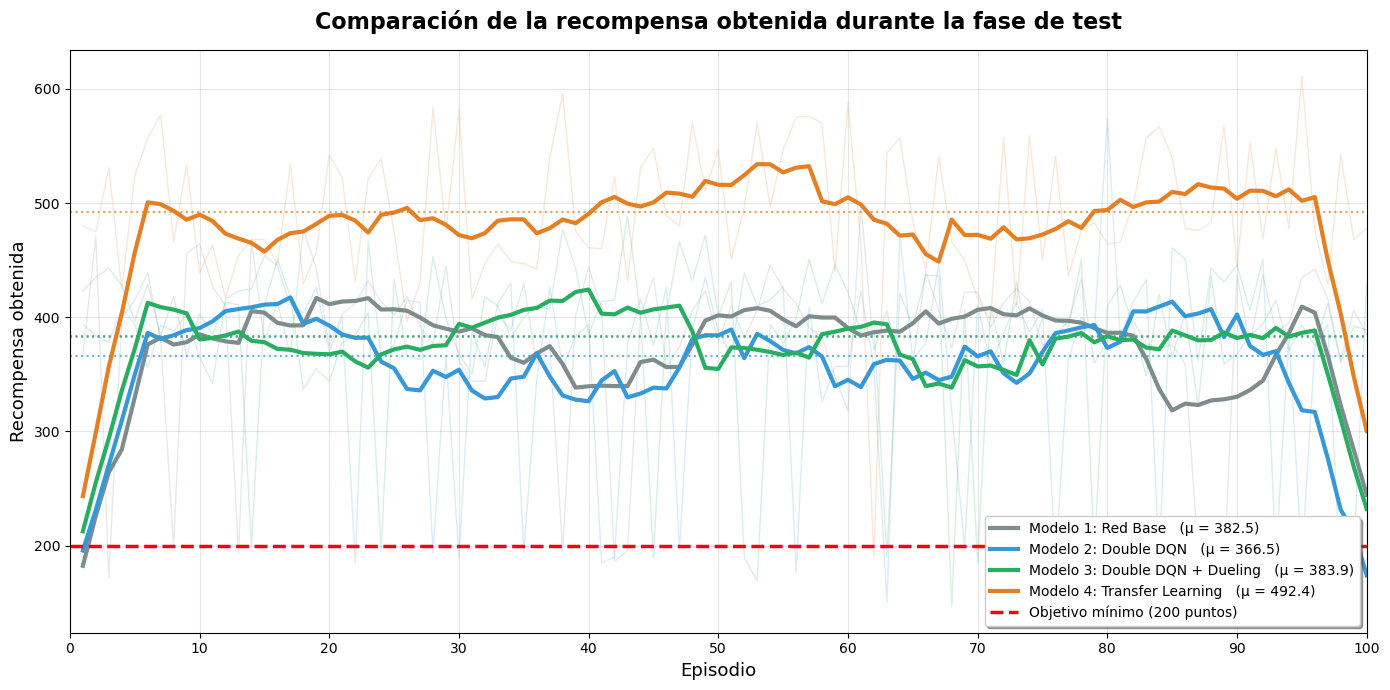

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt


def media_movil(x, window=10):
    return np.convolve(x, np.ones(window) / window, mode='same')

files = [
    "test/model1.json",
    "test/model2.json",
    "test/model3.json",
    "test/model4.json"
]

datos = []

for file in files:
    with open(file, "r") as f:
        datos.append(json.load(f))


plt.figure(figsize=(14,7))
episodios = np.arange(1,101)
colors = ["#7f8c8d", "#3498db", "#27ae60", "#e67e22"]

for i, d in enumerate(datos):
    recompensas = np.array(d["recompensas"])
    media = np.mean(recompensas)
    plt.plot(
        episodios,
        recompensas,
        color=colors[i],
        alpha=0.18,
        linewidth=1
    )

    # Media movil
    plt.plot(
        episodios,
        media_movil(recompensas, window=10),
        color=colors[i],
        linewidth=3,
        label=f'{d["nombre"]}   (μ = {media:.1f})'
    )

    plt.axhline(media, color=colors[i], linestyle=":", linewidth=1.5, alpha=0.75)

recompensa_minima = 200
plt.axhline(recompensa_minima, color="red", linestyle="--", linewidth=2.5, label=f"Objetivo mínimo ({recompensa_minima} puntos)")
plt.title("Comparación de la recompensa obtenida durante la fase de test", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Episodio", fontsize=13)
plt.ylabel("Recompensa obtenida", fontsize=13)
plt.xlim(1,100)
plt.xticks(np.arange(0,101,10))
plt.grid(True, alpha=0.30)
plt.legend(loc="lower right", fontsize=10, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()

Esta primera gráfica compara la recompensa obtenida durante los 100 episodios de test para los cuatro modelos desarrollados. En primer lugar, puede observarse que todos ellos superan el objetivo de 200 puntos, representado por la línea roja discontinua. Sin embargo, existen diferencias importantes en cuanto a rendimiento y estabilidad. La DQN tradicional y la combinación de Double DQN con Dueling DQN presentan un comportamiento muy similar, mientras que la versión con únicamente Double DQN obtiene una recompensa media inferior y muestra una mayor variabilidad. Por el contrario, el modelo basado en Transfer Learning destaca claramente sobre el resto, manteniendo recompensas cercanas a los 500 puntos durante la mayor parte de los episodios y alcanzando la mayor media de todos los experimentos (492.4 puntos). 

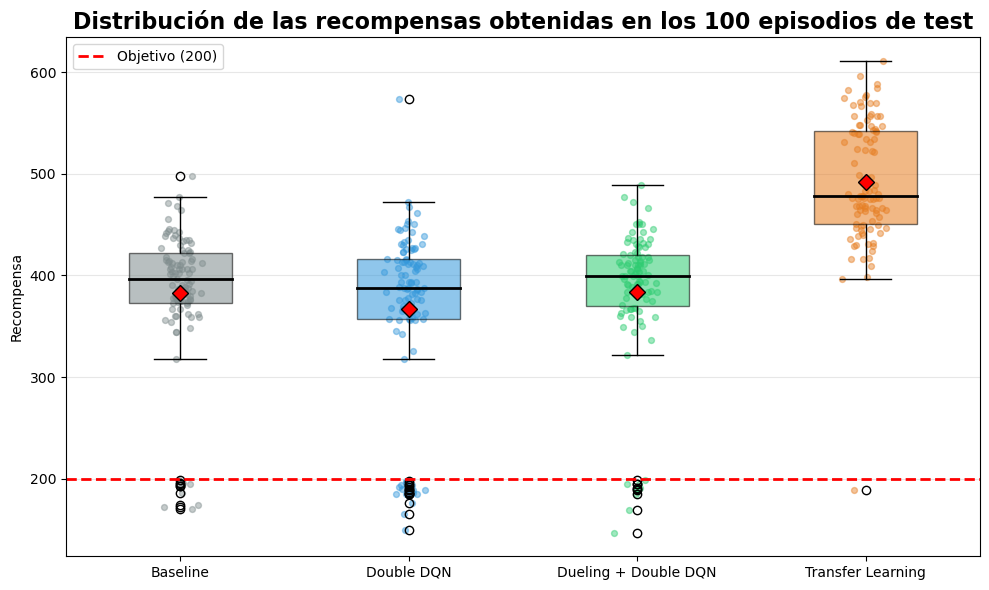

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

files = [
    ("Baseline", "test/model1.json", "#7f8c8d"),
    ("Double DQN", "test/model2.json", "#3498db"),
    ("Dueling + Double DQN", "test/model3.json", "#2ecc71"),
    ("Transfer Learning", "test/model4.json", "#e67e22")
]

data = []
colors = []

plt.figure(figsize=(10,6))

for name, file, color in files:

    with open(file, "r") as f:
        log = json.load(f)

    data.append(log["recompensas"])
    colors.append(color)

bp = plt.boxplot(
    data,
    patch_artist=True,
    labels=[f[0] for f in files],
    showmeans=True,
    meanprops=dict(
        marker='D',
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=8
    ),
    medianprops=dict(
        color='black',
        linewidth=2
    )
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for i, valores in enumerate(data, start=1):

    x = np.random.normal(i, 0.04, size=len(valores))

    plt.scatter(
        x,
        valores,
        color=colors[i-1],
        alpha=0.45,
        s=18
    )

plt.axhline(
    200,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Objetivo (200)"
)

plt.title(
    "Distribución de las recompensas obtenidas en los 100 episodios de test",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Recompensa")
plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

Los modelos presentan también diferencias en cuanto a dispersión. El modelo Transfer Learning destaca claramente al presentar la mediana y la media más elevadas, además de concentrar la mayor parte de los episodios entre aproximadamente 450 y 550 puntos, reflejando un comportamiento más consistente a altos niveles de recompensa. Por el contrario, la versión con Double DQN muestra la media más baja y una mayor presencia de episodios con recompensas reducidas. La DQN tradicional y la combinación Double DQN + Dueling DQN presentan distribuciones muy similares, siendo esta última ligeramente superior tanto en mediana como en media.

### Entrenamiento

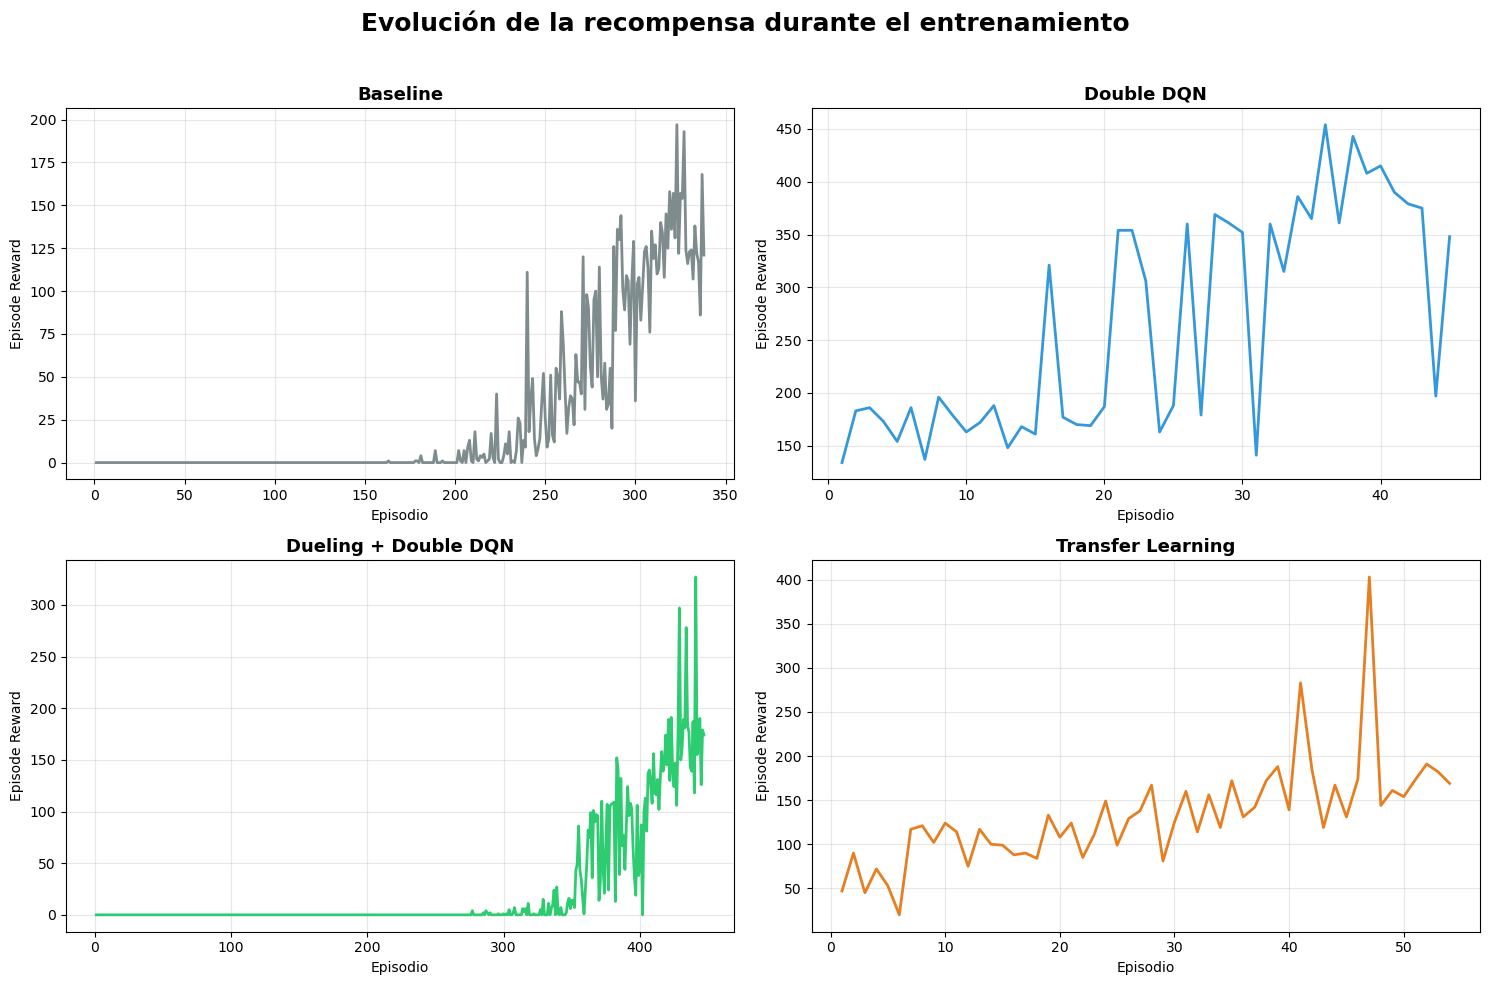

In [60]:
import json
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

files = [
    ("Baseline", "model1/dqn_Enduro-v0_model1_log.json", "#7f8c8d"),
    ("Double DQN", "model2/dqn_Enduro-v0_model2_log.json", "#3498db"),
    ("Dueling + Double DQN", "model3/dqn_Enduro-v0_model3_log.json", "#2ecc71"),
    ("Transfer Learning", "model4/dqn_Enduro-v0_model4_log.json", "#e67e22")
]

for ax, (title, file, color) in zip(axs, files):

    with open(file) as f:
        data = json.load(f)

    reward = np.array(data["episode_reward"])
    episodes = np.arange(1, len(reward)+1)

    ax.plot(
        episodes,
        reward,
        color=color,
        linewidth=2
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Episode Reward")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Evolución de la recompensa durante el entrenamiento",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

Esta gráfica muestra la evolución de la recompensa obtenida durante el entrenamiento de los distintos modelos. En todos los casos puede observarse una tendencia creciente, lo que indica que el agente va aprendiendo progresivamente una política cada vez más eficaz. La DQN tradicional requiere un gran número de episodios antes de comenzar a mejorar de forma apreciable, mientras que la combinación de Double DQN y Dueling DQN presenta una evolución similar, aunque con un crecimiento algo más rápido en las fases finales. En el caso de Double DQN, la recompensa parte de valores más elevados al reutilizar los pesos entrenados previamente con la DQN tradicional, aunque el entrenamiento muestra una mayor variabilidad entre episodios, lo que coincide con el menor rendimiento obtenido durante la fase de test. Por último, el modelo basado en Transfer Learning también comienza con un rendimiento elevado al partir del mejor modelo obtenido anteriormente y ajustar únicamente las capas finales de la red. Esto le permite alcanzar un buen rendimiento con un número de episodios mucho menor, confirmando que la reutilización de los pesos acelera significativamente el proceso de aprendizaje.

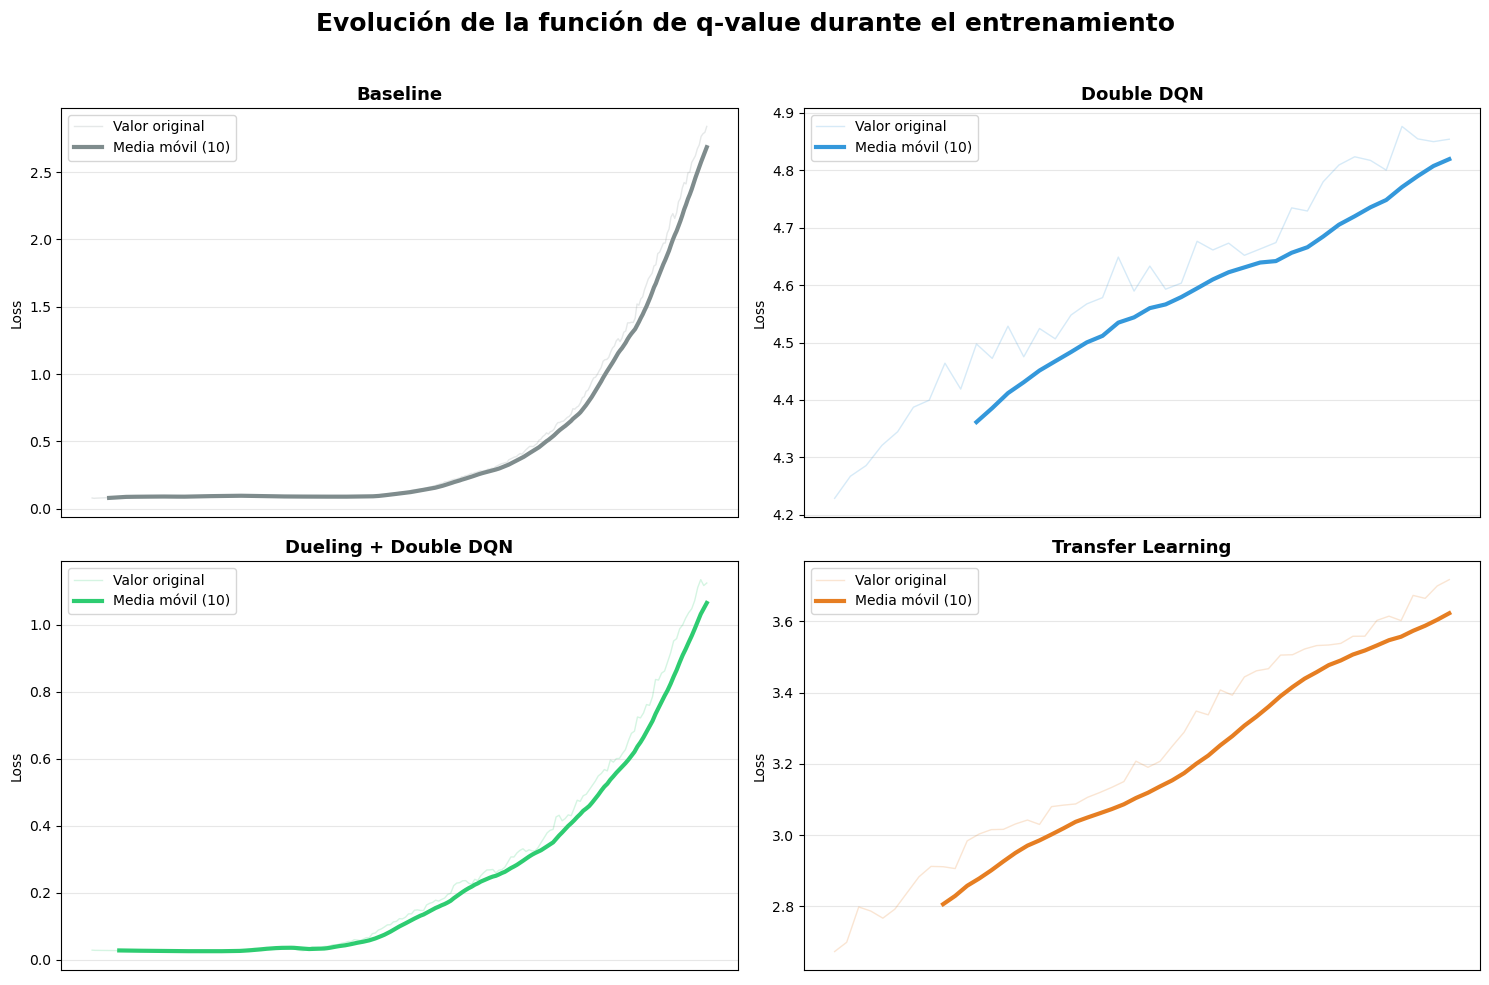

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

WINDOW = 10

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for ax, (title, file, color) in zip(axs, files):

    with open(file) as f:
        data = json.load(f)

    values = np.array(data["mean_q"], dtype=float)  

    valid = ~np.isnan(values)
    values = values[valid]


    episodes = np.arange(1, len(values) + 1)

    ax.plot(
        episodes,
        values,
        color=color,
        alpha=0.20,
        linewidth=1,
        label="Valor original"
    )

    if len(values) >= WINDOW:
        moving = np.convolve(values, np.ones(WINDOW)/WINDOW, mode="valid")

        ax.plot(
            episodes[WINDOW-1:],
            moving,
            color=color,
            linewidth=3,
            label=f"Media móvil ({WINDOW})"
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    "Evolución de la función de q-value durante el entrenamiento",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

Esta última gráfica muestra la evolución del Q-value medio estimado durante el entrenamiento para los distintos modelos. En todos los casos se observa una tendencia creciente, lo que indica que el agente va asignando valores cada vez mayores a las acciones que considera más beneficiosas conforme mejora su política. La DQN tradicional y la combinación de Double DQN y Dueling DQN parten de valores reducidos y aumentan progresivamente a medida que avanza el entrenamiento. Por su parte, Double DQN y Transfer Learning comienzan con estimaciones más elevadas al reutilizar pesos previamente entrenados, reflejando que el agente ya dispone de una política inicial sobre la que seguir aprendiendo.

### Conclusiones

Quizá uno de los aspectos que ha desvelado este trabajo es que, a la hora de entrenar una DQN y, por extensión, otros modelos de aprendizaje por refuerzo, lo que realmente marca la diferencia no es únicamente el algoritmo utilizado, sino una correcta selección de los hiperparámetros y de la estrategia de entrenamiento. En este trabajo se ha observado que una DQN tradicional bien ajustada puede ser más efectiva que una Double DQN cuyos parámetros no hayan sido optimizados adecuadamente. Es muy probable que una Double DQN entrenada desde cero y con una configuración más afinada termine superando a la DQN tradicional.

Por otra parte, la estrategia que mejores resultados ha proporcionado ha sido la basada en Transfer Learning. Aprovechar el conocimiento aprendido por el mejor modelo previo y realizar un ajuste de las capas finales permitió alcanzar una recompensa media de 492.38 puntos, muy por encima del resto de modelos, utilizando además un entrenamiento adicional considerablemente más corto. Por este motivo, este modelo ha sido seleccionado como el modelo final del proyecto.

En todo caso, todos los modelos han superado ampliamente el criterio de los 200 adelantamientos establecido como requisito mínimo, por lo que puede considerarse que el objetivo del trabajo se ha cumplido satisfactoriamente.

Otra problemática que ha puesto de manifiesto este trabajo es el elevado poder de cómputo requerido por este tipo de entrenamientos. Varios miembros del grupo mantuvieron sus ordenadores ejecutando experimentos durante varios días para, en ocasiones, obtener resultados que obligaron a reajustar los hiperparámetros y repetir el proceso. Se trata de un procedimiento costoso tanto en tiempo como en recursos, por lo que resulta fundamental realizar un análisis previo del problema y seleccionar cuidadosamente los parámetros antes de iniciar entrenamientos largos. Asimismo, el uso de checkpoints y el seguimiento continuo del entrenamiento resultan esenciales para evitar perder el progreso conseguido tras varias jornadas de ejecución.

---